# Preprocessing Restaurant Reviews Dataset

## 10000 Restaurant Reviews Dataset

In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("joebeachcapital/restaurant-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'restaurant-reviews' dataset.
Path to dataset files: /kaggle/input/restaurant-reviews


In [2]:
from pathlib import Path

ROOT = Path.cwd()
DATA = ROOT / "data" / "datasets"

DATA.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv([p for p in Path(path).iterdir() if p.exists()][0])
df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [4]:
df.shape

(10000, 8)

In [5]:
df = df.drop(columns=['7514', 'Pictures', 'Metadata'], axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Time        9962 non-null   object
dtypes: object(5)
memory usage: 390.8+ KB


In [7]:
df.isna().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Time,38


In [8]:
df = df.dropna(subset=['Review', 'Reviewer', 'Rating'])

In [9]:
df.isna().sum()

,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Time,0


In [10]:
df['Rating'].unique()

array(['5', '4', '1', '3', '2', '3.5', '4.5', '2.5', '1.5', 'Like'],
      dtype=object)

In [11]:
df = df[df['Rating'] != 'Like']

In [12]:
df['Rating'] = df['Rating'].astype(float).astype(int)

In [13]:
df = df[df['Rating'].between(1, 5)]

In [14]:
df['Rating'].unique()

array([5, 4, 1, 3, 2])

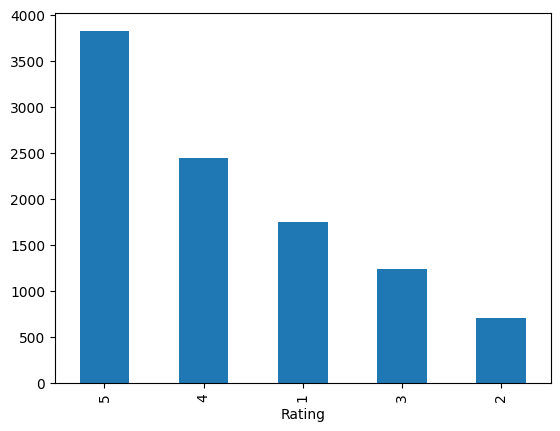

In [15]:
df.Rating.value_counts().plot(kind='bar');

In [16]:
import re

def clean_text(t):
  t = str(t).lower()
  t = re.sub(r'<.*?>', '', t)   # remove HTML tags
  t = re.sub(r'\s+', ' ', t).strip()
  return t

In [17]:
df['Review'] = df['Review'].apply(clean_text)

In [18]:
df.head()

,Restaurant,Reviewer,Review,Rating,Time
0,Beyond Flavours,Rusha Chakraborty,"the ambience was good, food was quite good . h...",5,5/25/2019 15:54
1,Beyond Flavours,Anusha Tirumalaneedi,ambience is too good for a pleasant evening. s...,5,5/25/2019 14:20
2,Beyond Flavours,Ashok Shekhawat,a must try.. great food great ambience. thnx f...,5,5/24/2019 22:54
3,Beyond Flavours,Swapnil Sarkar,soumen das and arun was a great guy. only beca...,5,5/24/2019 22:11
4,Beyond Flavours,Dileep,food is good.we ordered kodi drumsticks and ba...,5,5/24/2019 21:37


## Finding potential AI content

In [19]:
# Convert to datetime if available
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

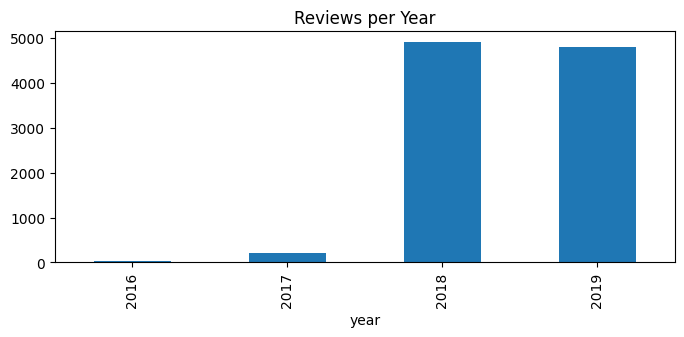

In [20]:
import matplotlib.pyplot as plt

# review count by year
df['year'] = df['Time'].dt.year
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(8, 3))
plt.title("Reviews per Year")
plt.show()

In [21]:
print(f"Oldest date: {df['Time'].min()}")
print(f"Latest date: {df['Time'].max()}")

Oldest date: 2016-05-31 16:41:00
Latest date: 2019-05-25 20:23:00


In [22]:
# find clusters of identical or near-identical reviews (possible AI)
dup_reviews = df['Review'].value_counts()
suspicious = dup_reviews[dup_reviews > 3]
print("Potentially synthetic patterns:", len(suspicious))

Potentially synthetic patterns: 33


In [23]:
df['length'] = df['Review'].str.len()
df['word_count'] = df['Review'].str.split().apply(len)
print(df[['length','word_count']].describe())

            length   word_count
count  9954.000000  9954.000000
mean    279.210368    50.172895
std     337.346142    60.784573
min       1.000000     1.000000
25%     144.000000    24.000000
50%     189.000000    34.000000
75%     321.000000    58.000000
max    5212.000000   964.000000


In [24]:
# find overly long / short extremes
df['suspicious_len'] = (df['word_count'] < 5) | (df['word_count'] > 500)

# find duplicate reviews per restaurant
dup_mask = df.duplicated(subset=['Review','Restaurant'], keep=False)
df['suspicious_dup'] = dup_mask

# Combine
df['possible_ai'] = df['suspicious_len'] | df['suspicious_dup']
print(df['possible_ai'].mean())

0.12989752863170584


In [25]:
# filter rows flagged as possibly AI-generated
suspect_reviews = df[df['possible_ai'] == 1]

print(f"Total possible AI-generated reviews: {len(suspect_reviews)}")

Total possible AI-generated reviews: 1293


In [26]:
df.columns = df.columns.str.lower()

In [27]:
suspect_reviews[['Restaurant', 'Review', 'Rating']].sample(20)

,Restaurant,Review,Rating
4161,Karachi Bakery,nice,4
3580,Green Bawarchi Restaurant,good,5
6789,Yum Yum Tree - The Arabian Food Court,food was delivered cold,3
6211,Shree Santosh Dhaba Family Restaurant,good test,5
5139,Hitech Bawarchi Food Zone,good delivery in time,5
5793,Being Hungry,not so good..,2
6269,Shree Santosh Dhaba Family Restaurant,superb fast service...thank you...,5
9669,Hyderabadi Daawat,very delicious,5
5870,Tempteys,good,5
6355,Dine O China,poor quality,2


In [28]:
# removing 13% possible ai reviews
df = df[df['possible_ai'] == 0].copy()

In [29]:
df.shape

(8661, 11)

## Metadata Extraction

In [30]:
df.restaurant.nunique()

100

In [31]:
# Clean up restaurant names
df['restaurant_name'] = df['restaurant'].str.strip()
df['rating_value'] = df['rating']

## Assign category (e.g., cuisine or type)

In [32]:
cuisine_keywords = {
    "Italian": ["pizza", "pasta", "italian"],
    "Mexican": ["mexican", "taco", "burrito"],
    "Chinese": ["chinese", "noodle", "dim sum"],
    "Indian": ["indian", "curry", "biryani", "tandoori"],
    "Japanese": ["japanese", "sushi", "ramen"],
    "Thai": ["thai", "pad thai"],
    "Seafood": ["seafood", "fish", "crab", "lobster"],
    "Steakhouse": ["steak", "grill", "barbecue"],
    "Cafe": ["cafe", "coffee", "espresso"],
    "Dessert": ["dessert", "bakery", "cake", "ice cream"],
    "Bar": ["bar", "pub", "brewery"]
}

def infer_category(row):
    text = f"{row['restaurant_name']} {row['review']}".lower()
    for category, keywords in cuisine_keywords.items():
        if any(kw in text for kw in keywords):
            return category
    return "General"

df['category'] = df.apply(infer_category, axis=1)

In [33]:
df.category.value_counts()

,count
category,
General,4272
Indian,1325
Italian,595
Bar,513
Dessert,501
Steakhouse,421
Chinese,417
Cafe,301
Seafood,239


## Extract descriptive keywords

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

reviews = df['review']

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(reviews)

# Get top 3 keywords per review
feature_names = vectorizer.get_feature_names_out()

def top_keywords(row_idx):
    row = tfidf_matrix[row_idx].toarray().flatten()
    top_indices = row.argsort()[-3:][::-1]
    return [feature_names[i] for i in top_indices]

df['keywords'] = [top_keywords(i) for i in range(len(df))]

In [35]:
df[['restaurant_name', 'rating_value', 'category', 'keywords']].sample(10)

,restaurant_name,rating_value,category,keywords
387,Shah Ghouse Hotel & Restaurant,4,Indian,"[irani, chai, offers]"
3361,Club Rogue,1,General,"[loud, asked, places]"
708,Shah Ghouse Spl Shawarma,1,General,"[ghouse, shah, shawarma]"
353,Shah Ghouse Hotel & Restaurant,3,Indian,"[ordered, double, regular]"
1578,KFC,4,General,"[asked, money, kfc]"
8763,American Wild Wings,2,General,"[glass, improvement, needs]"
2917,Hunger Maggi Point,1,General,"[bad, maggie, really]"
4401,La La Land - Bar & Kitchen,5,Bar,"[impressive, attitude, weekend]"
5000,Gal Punjab Di,4,Indian,"[paneer, rotis, specially]"
889,Hyper Local,3,Italian,"[veg, terminus, sln]"


In [36]:
df.to_csv(DATA / "cleaned_reviews.csv", index=False)

## Create Splits

In [37]:
from sklearn.model_selection import train_test_split

df_prompt, df_holdout = train_test_split(df, test_size=0.2, stratify=df['rating'], random_state=42)

df_prompt.to_csv(DATA / "prompt_bank.csv", index=False)
df_holdout.to_csv(DATA / "holdout.csv", index=False) # create a held-out data for few-shot experiments

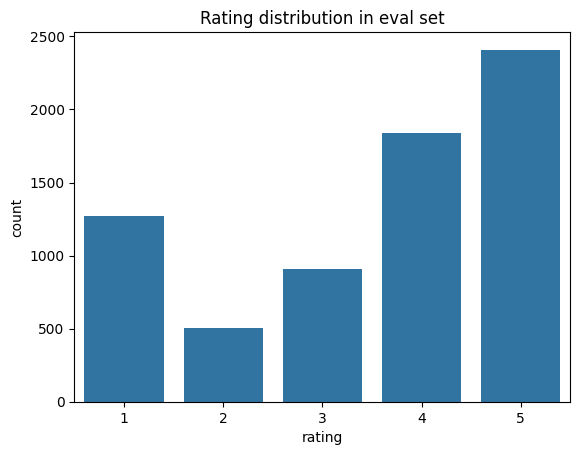

In [38]:
import seaborn as sns

sns.countplot(x='rating', data=df_prompt)
plt.title("Rating distribution in eval set")
plt.show()